# Entrega 2 — Experimentación Metodológica Unificada
## Predicción de Deserción Estudiantil: Invarianza entre PreTec21 y Tec21
**Equipo 7 · Desarrollo de Aplicaciones Avanzadas de Ciencias Computacionales**

---
Este notebook implementa el pipeline completo de experimentación, partiendo del dataset
ya procesado por el pipeline de preprocesamiento.

**Fuente de datos recomendada:** `data/dataset_engineered.csv`
(salida de `data/preprocessing/03_feature_engineering.ipynb`)

**Pipeline completo:**
```
01_missingness_diagnosis → 02_imputation_pipeline → 03_feature_engineering → este notebook
```

**Modelos implementados:**
- K-Means clustering por régimen (PreTec21 / Tec21)
- Regresión Logística (global + por régimen)
- Árbol de Decisión (global + por régimen)
- Random Forest con SHAP (global + por régimen)
- XGBoost con SHAP (global + por régimen)
- Modelos específicos por subgrupo/cluster (Random Forest)

## 1. Setup e Importaciones

In [56]:
import warnings; warnings.filterwarnings('ignore')
import time, os
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr

# Clustering
from sklearn.cluster          import KMeans
from sklearn.metrics          import silhouette_score, davies_bouldin_score
from sklearn.preprocessing    import StandardScaler
from sklearn.decomposition    import PCA
from sklearn.impute           import SimpleImputer

# Modelos supervisados
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import (
    StratifiedKFold, cross_validate, RandomizedSearchCV,
    train_test_split, learning_curve
)
from sklearn.metrics          import (
    roc_auc_score, recall_score, f1_score, precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve
)

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print("✓ XGBoost disponible:", xgb.__version__)
except ImportError:
    XGB_AVAILABLE = False
    print("⚠ XGBoost no disponible — instalar con: pip install xgboost --break-system-packages")

try:
    import shap
    SHAP_AVAILABLE = True
    print("✓ SHAP disponible:", shap.__version__)
except ImportError:
    SHAP_AVAILABLE = False
    print("⚠ SHAP no disponible — instalar con: pip install shap --break-system-packages")

SEED = 42
np.random.seed(SEED)
print("\n✓ Librerías cargadas correctamente")

✓ XGBoost disponible: 3.2.0
✓ SHAP disponible: 0.51.0

✓ Librerías cargadas correctamente


## 2. Configuración

In [57]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DATASET_MODE controla qué archivo se lee:
#
#   'engineered' → data/dataset_engineered.csv  ✓ RECOMENDADO
#                  (salida del pipeline 03_feature_engineering)
#                  Feature engineering ya aplicado — sección 4 es mínima.
#
#   'imputed'    → data/dataset_imputed.csv
#                  Pipeline de imputación solo — requiere más transformaciones.
#
#   'kmeans'     → data/dataset_k_means.csv
#                  Dataset legacy con ingeniería previa (versión anterior).
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATASET_MODE = 'imputed'   # ← cambiar aquí si se quiere otro dataset

DATA_DIR  = Path('../data')
IMG_DIR   = Path('../data/images'); IMG_DIR.mkdir(exist_ok=True)

# Generaciones por régimen
PRETEC21_GENS = ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
TEC21_GENS    = ['AD19', 'AD20']
TARGET        = 'retention'

# Número de clusters (referencia del análisis exploratorio previo)
K_CLUSTERS = 4

# Métricas de éxito
MIN_SILHOUETTE = 0.30
MAX_DB         = 1.50
MIN_AUC        = 0.60

print(f"DATASET_MODE  : {DATASET_MODE}")
print(f"K_CLUSTERS    : {K_CLUSTERS}")
print(f"PreTec21 gens : {PRETEC21_GENS}")
print(f"Tec21 gens    : {TEC21_GENS}")

DATASET_MODE  : imputed
K_CLUSTERS    : 4
PreTec21 gens : ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
Tec21 gens    : ['AD19', 'AD20']


## 3. Carga del Dataset

In [58]:
if DATASET_MODE == 'engineered':
    csv_path = DATA_DIR / 'dataset_engineered.csv'
elif DATASET_MODE == 'imputed':
    csv_path = DATA_DIR / 'dataset_imputed.csv'
else:
    csv_path = DATA_DIR / 'dataset_k_means.csv'

if not csv_path.exists():
    raise FileNotFoundError(
        f"Archivo no encontrado: {csv_path}\n"
        f"{'→ Ejecutar 03_feature_engineering.ipynb primero' if DATASET_MODE == 'engineered' else ''}"
        f"{'→ Ejecutar 02_imputation_pipeline.ipynb primero' if DATASET_MODE == 'imputed' else ''}"
    )

t0 = time.time()
df_raw = pd.read_csv(csv_path, low_memory=False)
print(f"✓ {csv_path.name} cargado en {time.time()-t0:.1f}s  →  {df_raw.shape}")

print(f"\nDistribución por generación:")
print(df_raw['generation'].value_counts().sort_index().to_string())

print(f"\nDistribución target (retention):")
counts = df_raw[TARGET].value_counts()
print(f"  Retuvo  (1): {counts.get(1,0):>6,}  ({counts.get(1,0)/len(df_raw)*100:.1f}%)")
print(f"  Desertó (0): {counts.get(0,0):>6,}  ({counts.get(0,0)/len(df_raw)*100:.1f}%)")

✓ dataset_imputed.csv cargado en 0.3s  →  (77517, 58)

Distribución por generación:
generation
AD14    10143
AD15    10041
AD16    10742
AD17    10788
AD18    11296
AD19    12199
AD20    12308

Distribución target (retention):
  Retuvo  (1): 70,704  (91.2%)
  Desertó (0):  6,813  (8.8%)


## 4. Ingeniería de Variables

Si `DATASET_MODE == 'engineered'`: el dataset ya tiene todas las transformaciones aplicadas —
solo se hace una verificación y renombres menores si son necesarios.

Si `DATASET_MODE == 'imputed'` o `'kmeans'`: se aplica el pipeline completo de transformaciones.

In [59]:
def norm_admission_test(val):
    """PAA (>100) → 0-1; PAL (0-100) → /100; NaN → NaN."""
    if pd.isna(val): return np.nan
    try:
        f = float(val)
        return max(0.0, (f - 400) / 1200.0) if f > 100 else f / 100.0
    except Exception:
        return np.nan

EDU_ORD = {
    'No information': -1, 'MISSING': -1,
    'No degree': 0, 'Undergraduate degree': 1, 'Master degree': 2, 'PhD': 3,
}

if DATASET_MODE == 'engineered':
    # ── Dataset ya procesado por 03_feature_engineering.ipynb ────────────────
    df = df_raw.copy()

    # Verificación: columnas clave presentes
    expected_cols = ['PNA', 'admission_test_norm', 'apoyo_financiero',
                     'has_extracurriculars', 'first_gen_enc', 'educ_padres_max',
                     'socioec_enc', 'is_male', 'estuvo_prepa_tec', 'retention', 'regime']
    missing_cols  = [c for c in expected_cols if c not in df.columns]
    if missing_cols:
        print(f"⚠ Columnas esperadas no encontradas: {missing_cols}")
        print("  Verifica que ejecutaste 03_feature_engineering.ipynb")
    else:
        print(f"✓ Dataset engineered verificado — {df.shape[0]:,} filas × {df.shape[1]} columnas")

    # Renombres de compatibilidad si el dataset tiene nombre legacy
    rename_map = {'estuvo.prepa_tec': 'estuvo_prepa_tec'}
    df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

    # Eliminar columnas que no deben llegar al modelo (fuga o redundantes)
    EXTRA_DROP = ['level', 'average.first.period', 'failed.subject.first.period',
                  'dropped.subject.first.period', 'dropout.semester', 'program',
                  'id.school.origin', 'educational.model']
    df.drop(columns=[c for c in EXTRA_DROP if c in df.columns], inplace=True)

    print(f"Columnas finales ({df.shape[1]}): {sorted(df.columns.tolist())}")

elif DATASET_MODE == 'imputed':
    df = df_raw.copy()
    if 'level' in df.columns:
        df = df[df['level'] == 'Undergraduate'].copy()
        print(f"Filtrado nivel universitario: {len(df):,} registros")

    DROP_COLS = [
        'student.id', 'level', 'average.first.period', 'failed.subject.first.period',
        'dropped.subject.first.period', 'dropout.semester', 'program', 'id.school.origin',
        'scholarship.type', 'school.cost', 'parents.exatec', 'father.exatec', 'mother.exatec',
        'father.education.complete', 'father.education.summary',
        'mother.education.complete', 'mother.education.summary',
        'scholarship.perc', 'loan.perc', 'educational.model',
    ]
    df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)
    df['admission_test_norm'] = df['admission.test'].apply(norm_admission_test)
    df.drop(columns=['admission.test'], inplace=True)
    df['admission_test_norm'].fillna(df['admission_test_norm'].median(), inplace=True)

    def enc_first_gen(v):
        s = str(v).strip() if pd.notna(v) else ''
        return 1 if s == 'Yes' else (0 if s == 'No' else -1)
    df['first_gen_enc'] = df['first.generation'].apply(enc_first_gen)
    df.drop(columns=['first.generation'], inplace=True)

    df['educ_padres_max'] = df['max.degree.parents'].map(EDU_ORD).fillna(-1).astype(int)
    df.drop(columns=['max.degree.parents'], inplace=True)
    df.rename(columns={'total.scholarship.loan': 'apoyo_financiero'}, inplace=True)
    df['has_extracurriculars'] = df.get('has_life_activities', pd.Series(0, index=df.index)).copy()

    ACTIVITY_COLS = ['physical.education','cultural.diffusion','student.society',
                     'total.life.activities','athletic.sports','art.culture',
                     'student.society.leadership','life.work.mentoring','wellness.activities']
    df.drop(columns=[c for c in ACTIVITY_COLS + ['has_life_activities'] if c in df.columns], inplace=True)

    from sklearn.preprocessing import LabelEncoder
    df['is_male']        = df['gender'].map({'Male':1,'Female':0}).fillna(0).astype(int)
    df['estuvo_prepa_tec'] = df['tec.no.tec'].map({'TEC':1,'NO TEC':0}).fillna(0).astype(int)
    df['socioec_enc']    = df['socioeconomic.level'].map(
        {**{'No information':0,'MISSING':0},**{f'Level {i}':i for i in range(1,8)}}).fillna(0).astype(int)
    df['social_lag_enc'] = df['social.lag'].map(
        {'No information':0,'MISSING':0,'Low':1,'Medium':2,'High':3}).fillna(0).astype(int)
    le_school  = LabelEncoder(); df['school_enc']  = le_school.fit_transform(df['school'].fillna('Unknown').astype(str))
    le_region  = LabelEncoder(); df['region_enc']  = le_region.fit_transform(df['region'].fillna('Unknown').astype(str))
    foreign_dummies = pd.get_dummies(df['foreign'], prefix='foreign', drop_first=True, dtype=int)
    df = pd.concat([df, foreign_dummies], axis=1)
    df.drop(columns=[c for c in ['gender','tec.no.tec','socioeconomic.level','social.lag',
                                  'school','region','foreign','zone.type'] if c in df.columns], inplace=True)
    print(f"\n✓ Feature engineering completado. Shape: {df.shape}")

else:  # 'kmeans'
    df = df_raw.copy()
    df.rename(columns={'total.scholarship.loan': 'apoyo_financiero',
                        'admission.test'        : 'admission_test_norm'}, inplace=True)
    df['admission_test_norm'] = pd.to_numeric(df['admission_test_norm'], errors='coerce')
    df['admission_test_norm'] = df['admission_test_norm'].apply(
        lambda v: norm_admission_test(v) if pd.notna(v) and float(v) > 1.0 else v)
    if 'first_gen_enc' not in df.columns:
        df['first_gen_enc'] = df.get('first.generation.yes', pd.Series(0, index=df.index)).astype(int)
    if 'educ_padres_max' not in df.columns and 'max.degree.parents' in df.columns:
        df['educ_padres_max'] = df['max.degree.parents'].map(EDU_ORD).fillna(-1).astype(int)
        df.drop(columns=['max.degree.parents'], inplace=True)
    print(f"\n✓ Dataset k_means listo. Shape: {df.shape}")

Filtrado nivel universitario: 77,517 registros

✓ Feature engineering completado. Shape: (77517, 29)


## 5. Segmentación por Régimen

In [60]:
# Split por régimen educativo
pretec21_mask = df['generation'].isin(PRETEC21_GENS)
tec21_mask    = df['generation'].isin(TEC21_GENS)

df_pre  = df[pretec21_mask].copy().reset_index(drop=True)
df_tec  = df[tec21_mask].copy().reset_index(drop=True)

print(f"PreTec21 (AD14–AD18): {len(df_pre):,} estudiantes")
print(f"  Desertó: {(df_pre[TARGET]==0).sum():,}  ({(df_pre[TARGET]==0).mean()*100:.1f}%)")
print(f"  Retuvo : {(df_pre[TARGET]==1).sum():,}  ({(df_pre[TARGET]==1).mean()*100:.1f}%)")

print(f"\nTec21 (AD19–AD20): {len(df_tec):,} estudiantes")
print(f"  Desertó: {(df_tec[TARGET]==0).sum():,}  ({(df_tec[TARGET]==0).mean()*100:.1f}%)")
print(f"  Retuvo : {(df_tec[TARGET]==1).sum():,}  ({(df_tec[TARGET]==1).mean()*100:.1f}%)")

# Verificar que ambas particiones no estén vacías
assert len(df_pre) > 100, "PreTec21 muy pequeño — revisar generaciones"
assert len(df_tec) > 100, "Tec21 muy pequeño — revisar generaciones"
print("\n✓ Segmentación correcta")

PreTec21 (AD14–AD18): 53,010 estudiantes
  Desertó: 4,685  (8.8%)
  Retuvo : 48,325  (91.2%)

Tec21 (AD19–AD20): 24,507 estudiantes
  Desertó: 2,128  (8.7%)
  Retuvo : 22,379  (91.3%)

✓ Segmentación correcta


## 6. K-Means Clustering por Régimen

**Protocolo:** Se ajusta K-Means en PreTec21 y se proyectan los centroides en Tec21.  
Esto permite comparar si los perfiles latentes persisten tras el cambio pedagógico.

In [61]:
# Definir columnas de clustering (variables continuas clave)
CLUSTER_COLS_CANDIDATES = [
    'PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric',
    'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc',
    'educ_padres_max', 'FTE', 'age',
]
CLUSTER_COLS = [c for c in CLUSTER_COLS_CANDIDATES if c in df.columns]
print(f"Variables de clustering ({len(CLUSTER_COLS)}): {CLUSTER_COLS}")

# Preparar matrices
X_clust_pre_df = df_pre[CLUSTER_COLS].copy()
X_clust_tec_df = df_tec[CLUSTER_COLS].copy()

# Imputar medianas del PreTec21 (nunca del test)
clust_medians = X_clust_pre_df.median()
X_clust_pre_df.fillna(clust_medians, inplace=True)
X_clust_tec_df.fillna(clust_medians, inplace=True)

# Estandarizar con stats de PreTec21
scaler_clust = StandardScaler()
X_clust_pre  = scaler_clust.fit_transform(X_clust_pre_df.values.astype(float))
X_clust_tec  = scaler_clust.transform(X_clust_tec_df.values.astype(float))

print(f"\nPreTec21 clustering: {X_clust_pre.shape}")
print(f"Tec21    clustering: {X_clust_tec.shape}")

Variables de clustering (10): ['PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric', 'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc', 'educ_padres_max', 'FTE', 'age']

PreTec21 clustering: (53010, 10)
Tec21    clustering: (24507, 10)


  k=2  inertia=42,861  sil=0.142  DB=2.303
  k=3  inertia=36,610  sil=0.164  DB=1.796
  k=4  inertia=32,900  sil=0.177  DB=1.678
  k=5  inertia=29,953  sil=0.168  DB=1.684
  k=6  inertia=27,922  sil=0.175  DB=1.602
  k=7  inertia=26,536  sil=0.159  DB=1.655
  k=8  inertia=25,435  sil=0.154  DB=1.655


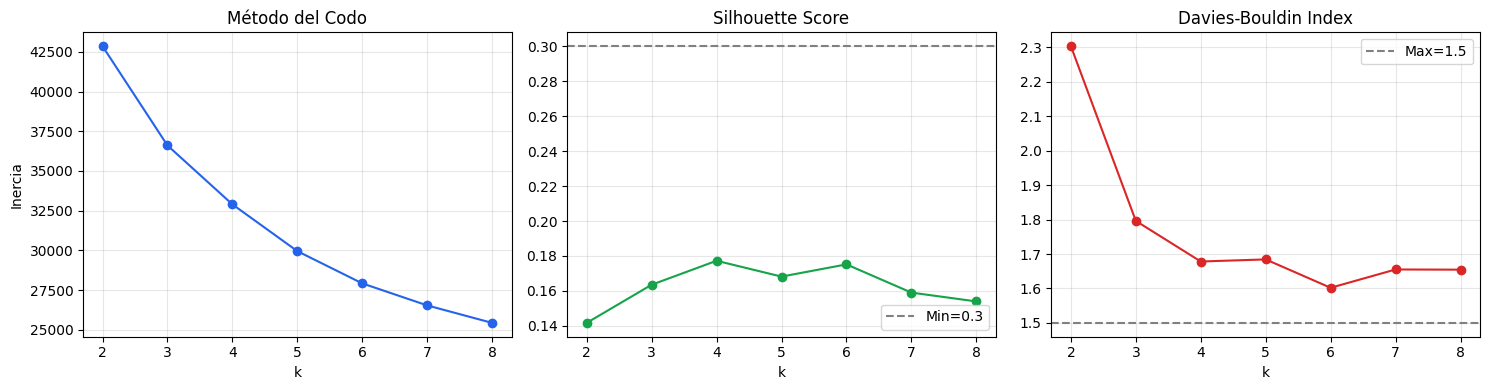


K recomendado por Silhouette: 4
K configurado (K_CLUSTERS)   : 4


In [62]:
# ── Selección de k óptimo ─────────────────────────────────────────────────────
inertias, silhouettes, db_scores = [], [], []
K_RANGE = range(2, 9)

# Usar submuestra si dataset muy grande
SAMPLE_SIZE = min(5000, len(X_clust_pre))
idx_sample  = np.random.choice(len(X_clust_pre), SAMPLE_SIZE, replace=False)
X_sample    = X_clust_pre[idx_sample]

for k in K_RANGE:
    km_tmp = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    lab    = km_tmp.fit_predict(X_sample)
    inertias.append(km_tmp.inertia_)
    silhouettes.append(silhouette_score(X_sample, lab))
    db_scores.append(davies_bouldin_score(X_sample, lab))
    print(f"  k={k}  inertia={km_tmp.inertia_:,.0f}  sil={silhouettes[-1]:.3f}  DB={db_scores[-1]:.3f}")

# Visualizar criterios
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(K_RANGE, inertias, 'o-', color='#2563eb'); axes[0].set_title('Método del Codo'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inercia'); axes[0].grid(alpha=0.3)
axes[1].plot(K_RANGE, silhouettes, 'o-', color='#16a34a'); axes[1].axhline(MIN_SILHOUETTE, ls='--', color='gray', label=f'Min={MIN_SILHOUETTE}'); axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(K_RANGE, db_scores, 'o-', color='#dc2626'); axes[2].axhline(MAX_DB, ls='--', color='gray', label=f'Max={MAX_DB}'); axes[2].set_title('Davies-Bouldin Index'); axes[2].set_xlabel('k'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(IMG_DIR / 'kmeans_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nK recomendado por Silhouette: {K_RANGE[np.argmax(silhouettes)]}")
print(f"K configurado (K_CLUSTERS)   : {K_CLUSTERS}")

In [63]:
# ── Entrenar K-Means final en PreTec21 ────────────────────────────────────────
km_final = KMeans(n_clusters=K_CLUSTERS, n_init=20, random_state=SEED)
km_final.fit(X_clust_pre)

labels_pre = km_final.labels_
labels_tec = km_final.predict(X_clust_tec)

df_pre = df_pre.copy(); df_pre['cluster'] = labels_pre
df_tec = df_tec.copy(); df_tec['cluster'] = labels_tec

# Métricas de calidad
sil_pre = silhouette_score(X_clust_pre, labels_pre)
db_pre  = davies_bouldin_score(X_clust_pre, labels_pre)
sil_tec = silhouette_score(X_clust_tec, labels_tec)
db_tec  = davies_bouldin_score(X_clust_tec, labels_tec)

print("═══ Métricas de Clustering ═══")
print(f"{'Métrica':<20} {'PreTec21':>10} {'Tec21':>10} {'Umbral':>10}")
print(f"{'Silhouette':<20} {sil_pre:>10.3f} {sil_tec:>10.3f} {'>= 0.30':>10}")
print(f"{'Davies-Bouldin':<20} {db_pre:>10.3f} {db_tec:>10.3f} {'<= 1.50':>10}")

ok_sil = (sil_pre >= MIN_SILHOUETTE) and (sil_tec >= MIN_SILHOUETTE)
ok_db  = (db_pre  <= MAX_DB)         and (db_tec  <= MAX_DB)
print(f"\n{'✓' if ok_sil else '✗'} Silhouette ≥ {MIN_SILHOUETTE}  |  {'✓' if ok_db else '✗'} Davies-Bouldin ≤ {MAX_DB}")

═══ Métricas de Clustering ═══
Métrica                PreTec21      Tec21     Umbral
Silhouette                0.177      0.177    >= 0.30
Davies-Bouldin            1.683      1.594    <= 1.50

✗ Silhouette ≥ 0.3  |  ✗ Davies-Bouldin ≤ 1.5


In [64]:
# ── Perfiles por cluster ───────────────────────────────────────────────────────
def cluster_profile(df_regime, regime_name):
    stats = (df_regime.groupby('cluster')
             .agg(n=(TARGET, 'count'),
                  tasa_desercion=(TARGET, lambda x: (x==0).mean()))
             .round(3))
    stats['pct_total'] = (stats['n'] / len(df_regime) * 100).round(1)
    stats = stats.sort_values('tasa_desercion', ascending=False)
    print(f"\n═══ Perfiles {regime_name} ═══")
    print(stats.to_string())
    return stats

stats_pre = cluster_profile(df_pre, 'PreTec21')
stats_tec = cluster_profile(df_tec, 'Tec21')

# Comparación
comp = pd.DataFrame({
    'PreTec21_%'     : stats_pre['pct_total'],
    'Tec21_%'        : stats_tec['pct_total'],
    'PreTec21_dropout': stats_pre['tasa_desercion'],
    'Tec21_dropout'  : stats_tec['tasa_desercion'],
}).round(3)
comp['Δ_%']       = (comp['Tec21_%']      - comp['PreTec21_%']).round(1)
comp['Δ_dropout'] = (comp['Tec21_dropout'] - comp['PreTec21_dropout']).round(3)
print("\n═══ Comparación de Distribución PreTec21 vs Tec21 ═══")
print(comp.to_string())


═══ Perfiles PreTec21 ═══
             n  tasa_desercion  pct_total
cluster                                  
1        21311           0.122       40.2
3         2644           0.109        5.0
0         9498           0.070       17.9
2        19557           0.058       36.9

═══ Perfiles Tec21 ═══
             n  tasa_desercion  pct_total
cluster                                  
2           38           0.763        0.2
1         1199           0.173        4.9
3         3129           0.129       12.8
0        20141           0.074       82.2

═══ Comparación de Distribución PreTec21 vs Tec21 ═══
         PreTec21_%  Tec21_%  PreTec21_dropout  Tec21_dropout   Δ_%  Δ_dropout
cluster                                                                       
0              17.9     82.2             0.070          0.074  64.3      0.004
1              40.2      4.9             0.122          0.173 -35.3      0.051
2              36.9      0.2             0.058          0.763 -36.7      0

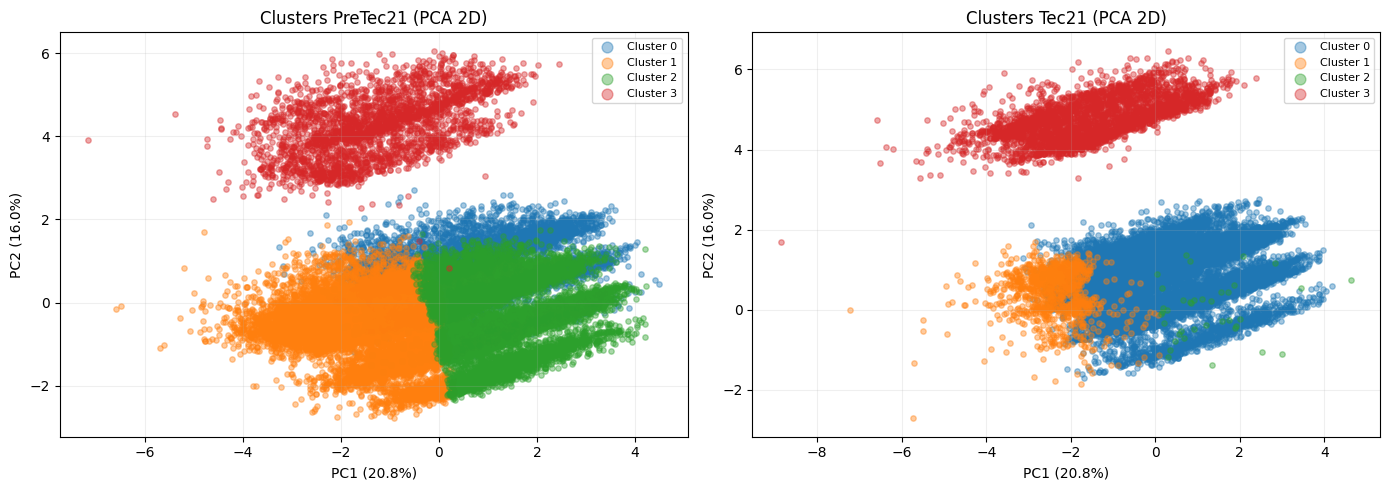

In [65]:
# ── Visualización de clusters (PCA 2D) ────────────────────────────────────────
pca = PCA(n_components=2, random_state=SEED)
pca.fit(X_clust_pre)
Z_pre = pca.transform(X_clust_pre)
Z_tec = pca.transform(X_clust_tec)

COLORS = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for regime_name, Z, labels, ax in [
    ('PreTec21', Z_pre, labels_pre, axes[0]),
    ('Tec21',    Z_tec, labels_tec, axes[1])
]:
    for k in range(K_CLUSTERS):
        mask = labels == k
        ax.scatter(Z[mask, 0], Z[mask, 1], s=15, alpha=0.4,
                   color=COLORS[k], label=f'Cluster {k}')
    ax.set_title(f'Clusters {regime_name} (PCA 2D)')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(markerscale=2, fontsize=8); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(IMG_DIR / 'clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

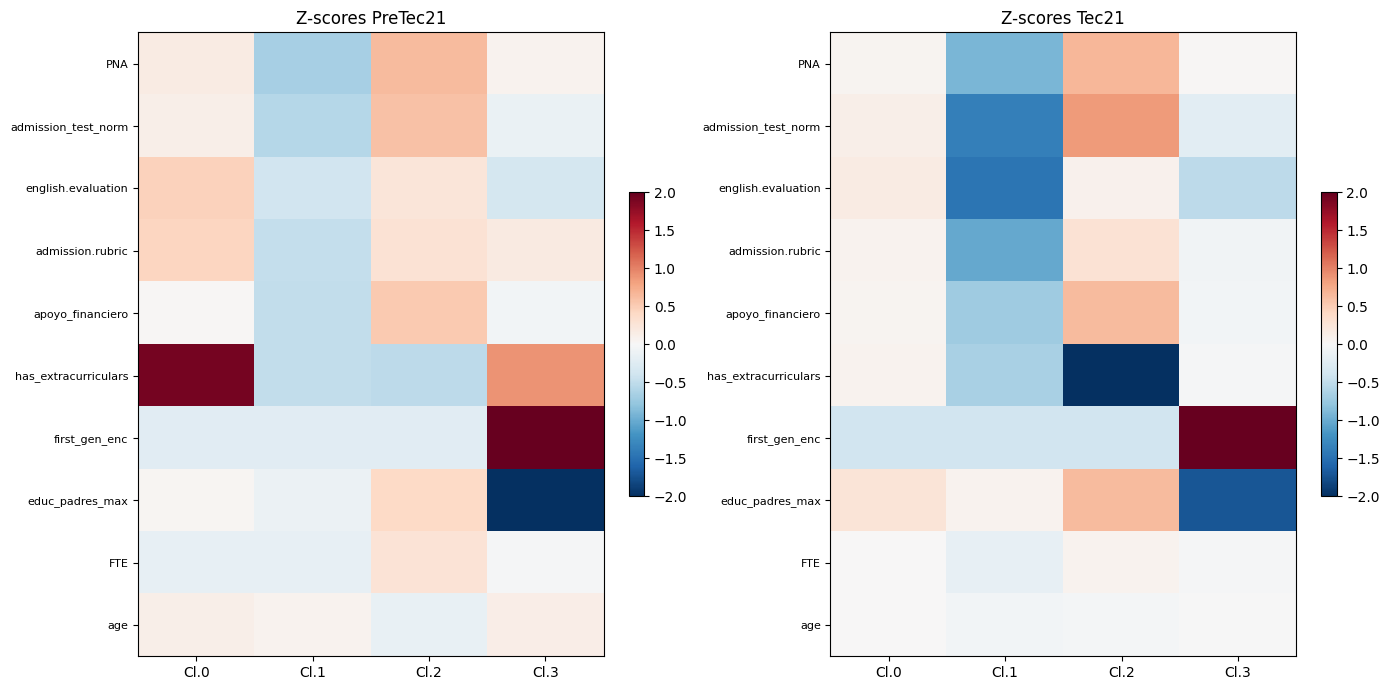

In [66]:
# ── Z-scores de variables clave por cluster ────────────────────────────────────
def zscore_profile(df_regime, cluster_cols, regime_name):
    clust_z = {}
    grand_mean = df_regime[cluster_cols].mean()
    grand_std  = df_regime[cluster_cols].std().replace(0, 1)
    for k in sorted(df_regime['cluster'].unique()):
        sub = df_regime[df_regime['cluster'] == k]
        z   = (sub[cluster_cols].mean() - grand_mean) / grand_std
        clust_z[k] = z
    return pd.DataFrame(clust_z)

z_pre = zscore_profile(df_pre, CLUSTER_COLS, 'PreTec21')
z_tec = zscore_profile(df_tec, CLUSTER_COLS, 'Tec21')

# Heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(CLUSTER_COLS)*0.5+2)))
for ax, z_df, title in [(axes[0], z_pre, 'Z-scores PreTec21'),
                          (axes[1], z_tec, 'Z-scores Tec21')]:
    im = ax.imshow(z_df.values, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
    ax.set_xticks(range(z_df.shape[1])); ax.set_xticklabels([f'Cl.{c}' for c in z_df.columns])
    ax.set_yticks(range(len(z_df.index))); ax.set_yticklabels(z_df.index, fontsize=8)
    ax.set_title(title); plt.colorbar(im, ax=ax, fraction=0.03)

plt.tight_layout()
plt.savefig(IMG_DIR / 'cluster_zscores.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Features y Split Train/Test para Modelos Supervisados

In [67]:
# ── Definir FEATURE_COLS para modelos supervisados ────────────────────────────
# Se detectan automáticamente según las columnas disponibles en el dataset.
# El dataset_engineered.csv ya tiene todo procesado.

FEATURE_COLS_CANDIDATES = [
    # Académicas / admisión
    'PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric',
    'general.math.eval', 'online.test',
    # Financiero / institucional
    'FTE', 'apoyo_financiero',
    # Actividades extracurriculares
    'has_extracurriculars', 'has_physical', 'has_cultural', 'has_social',
    # Socioeconómico y familiar
    'first_gen_enc', 'educ_padres_max', 'parents_exatec_enc',
    'socioec_enc', 'social_lag_enc',
    # Demográficas
    'age', 'is_male', 'estuvo_prepa_tec', 'estuvo.prepa_tec',
    # Foreign (puede ser one-hot o label)
    'foreign_Yes: Foreigner', 'foreign_Yes: National',
    # Zone
    'zone_enc', 'zone_Rural', 'zone_Semiurban', 'zone_Urban',
    # School / región (label encode)
    'school_enc', 'region_enc',
    # Indicadores MNAR / MCAR del pipeline
    'first_gen_present', 'parents_edu_present', 'took_admission_test',
    'has_socioeconomic_data', 'has_social_lag_data', 'has_zone_data',
    # Columnas legacy del dataset_k_means
    'first.generation.yes', 'first.generation.no', 'first.generation.no.information',
]

# Excluir target, cluster, identificadores y columnas que no deben entrar al modelo
EXCLUDE = {TARGET, 'cluster', 'generation', 'regime', 'educational.model',
           # school one-hot (alta dimensionalidad — usar school_enc en su lugar)
}

FEATURE_COLS = [c for c in FEATURE_COLS_CANDIDATES
                if c in df.columns and c not in EXCLUDE]

# Deduplicar (puede haber alias)
seen = set(); FEATURE_COLS = [c for c in FEATURE_COLS if c not in seen and not seen.add(c)]

print(f"Features finales ({len(FEATURE_COLS)}):")
for c in FEATURE_COLS:
    nulls = df[c].isna().sum()
    print(f"  {c:<40} dtype={df[c].dtype}  nulls={nulls}")

Features finales (26):
  PNA                                      dtype=float64  nulls=0
  admission_test_norm                      dtype=float64  nulls=0
  english.evaluation                       dtype=int64  nulls=0
  admission.rubric                         dtype=float64  nulls=0
  general.math.eval                        dtype=float64  nulls=0
  online.test                              dtype=int64  nulls=0
  FTE                                      dtype=float64  nulls=0
  apoyo_financiero                         dtype=float64  nulls=0
  has_extracurriculars                     dtype=int64  nulls=0
  first_gen_enc                            dtype=int64  nulls=0
  educ_padres_max                          dtype=int64  nulls=0
  socioec_enc                              dtype=int64  nulls=0
  social_lag_enc                           dtype=int64  nulls=0
  age                                      dtype=int64  nulls=0
  is_male                                  dtype=int64  nulls=0
  est

In [68]:
# ── Split 80/20 estratificado por régimen ─────────────────────────────────────
def make_split(df_regime, feature_cols, target=TARGET, seed=SEED):
    """Retorna (X_tr, X_te, y_tr, y_te) con columnas válidas."""
    cols = [c for c in feature_cols if c in df_regime.columns]
    X    = df_regime[cols].values.astype(float)
    y    = df_regime[target].values.astype(int)
    # Imputar medianas (solo columnas que llegan con NaN)
    imp  = SimpleImputer(strategy='median')
    X    = imp.fit_transform(X)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)
    return X_tr, X_te, y_tr, y_te, cols, imp

X_tr_pre, X_te_pre, y_tr_pre, y_te_pre, feat_pre, imp_pre = make_split(df_pre, FEATURE_COLS)
X_tr_tec, X_te_tec, y_tr_tec, y_te_tec, feat_tec, imp_tec = make_split(df_tec, FEATURE_COLS)

# Split global (todos)
df_all  = pd.concat([df_pre, df_tec], ignore_index=True)
X_tr_all, X_te_all, y_tr_all, y_te_all, feat_all, imp_all = make_split(df_all, FEATURE_COLS)

print(f"PreTec21  train: {X_tr_pre.shape}  test: {X_te_pre.shape}")
print(f"Tec21     train: {X_tr_tec.shape}  test: {X_te_tec.shape}")
print(f"Global    train: {X_tr_all.shape}  test: {X_te_all.shape}")

PreTec21  train: (42408, 26)  test: (10602, 26)
Tec21     train: (19605, 26)  test: (4902, 26)
Global    train: (62013, 26)  test: (15504, 26)


## 8. Función de Evaluación y Baseline

In [69]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name, feat_cols,
                   threshold=None, n_bootstrap=200, seed=SEED):
    """Entrena, evalúa y retorna dict de métricas + probabilidades."""
    model.fit(X_tr, y_tr)
    has_proba = hasattr(model, 'predict_proba')
    y_proba   = model.predict_proba(X_te)[:, 1] if has_proba else None

    # Umbral óptimo OOF (solo si hay probabilidades)
    if threshold is None and has_proba:
        skf_tmp = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
        oof = np.zeros(len(X_tr))
        for tr_i, va_i in skf_tmp.split(X_tr, y_tr):
            model.fit(X_tr[tr_i], y_tr[tr_i])
            oof[va_i] = model.predict_proba(X_tr[va_i])[:, 1]
        model.fit(X_tr, y_tr)  # re-entrenar en todo el train
        prec_oof, rec_oof, thr_oof = precision_recall_curve(y_tr, oof)
        f1_oof      = 2 * prec_oof * rec_oof / (prec_oof + rec_oof + 1e-8)
        threshold   = float(thr_oof[np.argmax(f1_oof[:-1])])

    y_pred = (y_proba >= threshold).astype(int) if (threshold is not None and has_proba) \
             else model.predict(X_te)

    # Métricas principales
    auc  = roc_auc_score(y_te, y_proba) if has_proba else 0.5
    rec  = recall_score(y_te, y_pred, zero_division=0)
    prec = precision_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)

    # Bootstrap IC para AUC
    rng  = np.random.default_rng(seed)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y_te), len(y_te))
        if y_proba is not None and len(np.unique(y_te[idx])) > 1:
            aucs.append(roc_auc_score(y_te[idx], y_proba[idx]))
    ci_lo, ci_hi = (np.percentile(aucs, [2.5, 97.5]) if aucs else (auc, auc))

    # ── FIX: formatear threshold fuera del f-string ───────────────────────────
    thr_str = f"{threshold:.2f}" if threshold is not None else "N/A"
    result = dict(model=model_name, auc=auc, ci_lo=ci_lo, ci_hi=ci_hi,
                  recall=rec, precision=prec, f1=f1,
                  threshold=threshold, y_proba=y_proba, y_pred=y_pred,
                  feat_cols=feat_cols)
    print(f"  {model_name:<28} AUC={auc:.3f} [{ci_lo:.3f},{ci_hi:.3f}]  "
          f"Recall={rec:.3f}  F1={f1:.3f}  thr={thr_str}")
    return result

print("✓ Función evaluate_model definida (bug f-string corregido)")

# ── Baseline (clase mayoritaria) ──────────────────────────────────────────────
print("\n═══ Baseline — clase mayoritaria (siempre predice retención) ═══")
for name, y_te in [('PreTec21', y_te_pre), ('Tec21', y_te_tec), ('Global', y_te_all)]:
    maj = np.ones_like(y_te)
    r   = recall_score(y_te, maj, zero_division=0)
    print(f"  {name:<12}  AUC=0.500  Recall={r:.3f}  F1≈0  (predice siempre retención)")

✓ Función evaluate_model definida (bug f-string corregido)

═══ Baseline — clase mayoritaria (siempre predice retención) ═══
  PreTec21      AUC=0.500  Recall=1.000  F1≈0  (predice siempre retención)
  Tec21         AUC=0.500  Recall=1.000  F1≈0  (predice siempre retención)
  Global        AUC=0.500  Recall=1.000  F1≈0  (predice siempre retención)


## 9. Modelos Globales (PreTec21 train → Tec21 test)

Entrenamos en **PreTec21** y evaluamos en **Tec21** para medir invarianza predictiva.

In [70]:
from sklearn.metrics import precision_recall_curve
from scipy.stats import randint

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results_global = []  # lista de dicts con métricas

print("═══ Regresión Logística ═══")
lr = LogisticRegression(class_weight='balanced', max_iter=2000,
                         random_state=SEED, solver='lbfgs')
res = evaluate_model(lr, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec,
                     'LogisticRegression', feat_pre)
results_global.append(res); lr_global = lr

═══ Regresión Logística ═══
  LogisticRegression           AUC=0.648 [0.622,0.670]  Recall=1.000  F1=0.955  thr=0.01


In [71]:
print("═══ Árbol de Decisión ═══")
# Buscar max_depth óptimo
best_dt, best_auc_dt, best_depth = None, 0, None
for depth in [4, 6, 8, 10, None]:
    dt_tmp = DecisionTreeClassifier(
        max_depth=depth, class_weight='balanced', random_state=SEED)
    cv_auc = cross_validate(dt_tmp, X_tr_pre, y_tr_pre,
                             cv=SKF, scoring='roc_auc', n_jobs=-1)['test_score'].mean()
    if cv_auc > best_auc_dt:
        best_auc_dt, best_depth, best_dt = cv_auc, depth, dt_tmp

print(f"  max_depth óptimo (CV): {best_depth}  →  AUC_CV={best_auc_dt:.3f}")
res = evaluate_model(best_dt, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec,
                     'DecisionTree', feat_pre)
results_global.append(res); dt_global = best_dt

═══ Árbol de Decisión ═══
  max_depth óptimo (CV): 4  →  AUC_CV=0.651
  DecisionTree                 AUC=0.583 [0.557,0.607]  Recall=1.000  F1=0.955  thr=0.11


In [72]:
print("═══ Random Forest ═══")
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=10,
    class_weight='balanced', random_state=SEED, n_jobs=-1)
res = evaluate_model(rf, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec,
                     'RandomForest', feat_pre)
results_global.append(res); rf_global = rf

═══ Random Forest ═══
  RandomForest                 AUC=0.655 [0.629,0.677]  Recall=1.000  F1=0.955  thr=0.18


In [73]:
if XGB_AVAILABLE:
    print("═══ XGBoost ═══")
    # Calcular scale_pos_weight para desbalance
    spw = float((y_tr_pre == 1).sum()) / max((y_tr_pre == 0).sum(), 1)
    xgb_model = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric='logloss',
        random_state=SEED, n_jobs=-1, verbosity=0)
    res = evaluate_model(xgb_model, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec,
                         'XGBoost', feat_pre)
    results_global.append(res); xgb_global = xgb_model
else:
    print("⚠ XGBoost no disponible — se omite")
    xgb_global = None

═══ XGBoost ═══
  XGBoost                      AUC=0.647 [0.623,0.671]  Recall=1.000  F1=0.955  thr=0.34


In [74]:
# ── Tabla comparativa de modelos globales ─────────────────────────────────────
def results_table(results):
    rows = []
    for r in results:
        rows.append({
            'Modelo'   : r['model'],
            'AUC-ROC'  : f"{r['auc']:.3f} [{r['ci_lo']:.3f},{r['ci_hi']:.3f}]",
            'Recall'   : f"{r['recall']:.3f}",
            'Precision': f"{r['precision']:.3f}",
            'F1'       : f"{r['f1']:.3f}",
            'OK_AUC'   : '✓' if r['auc'] >= MIN_AUC else '✗',
        })
    return pd.DataFrame(rows)

print("\n════════════════════════════════")
print("COMPARACIÓN GLOBAL DE MODELOS")
print("(Entrenado en PreTec21 → Evaluado en Tec21)")
print("════════════════════════════════")
tbl = results_table(results_global)
print(tbl.to_string(index=False))


════════════════════════════════
COMPARACIÓN GLOBAL DE MODELOS
(Entrenado en PreTec21 → Evaluado en Tec21)
════════════════════════════════
            Modelo             AUC-ROC Recall Precision    F1 OK_AUC
LogisticRegression 0.648 [0.622,0.670]  1.000     0.913 0.955      ✓
      DecisionTree 0.583 [0.557,0.607]  1.000     0.913 0.955      ✗
      RandomForest 0.655 [0.629,0.677]  1.000     0.913 0.955      ✓
           XGBoost 0.647 [0.623,0.671]  1.000     0.913 0.955      ✓


## 10. Curvas ROC y PR Comparativas

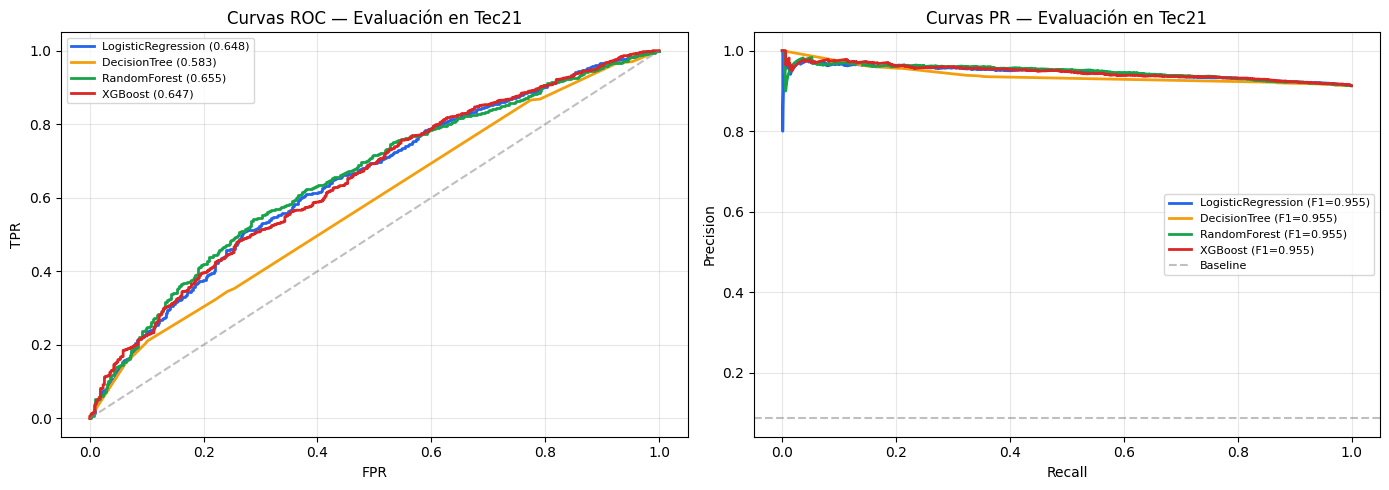

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'LogisticRegression':'#2563eb','DecisionTree':'#f59e0b',
           'RandomForest':'#16a34a','XGBoost':'#dc2626'}

for r in results_global:
    if r['y_proba'] is None: continue
    fpr, tpr, _ = roc_curve(y_te_tec, r['y_proba'])
    pr, rc, _   = precision_recall_curve(y_te_tec, r['y_proba'])
    col = palette.get(r['model'], 'gray')
    axes[0].plot(fpr, tpr, lw=2, color=col, label=f"{r['model']} ({r['auc']:.3f})")
    axes[1].plot(rc,  pr,  lw=2, color=col, label=f"{r['model']} (F1={r['f1']:.3f})")

axes[0].plot([0,1],[0,1],'--',color='gray',alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC — Evaluación en Tec21')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

no_skill = (y_te_tec == 0).mean()
axes[1].axhline(no_skill, ls='--', color='gray', alpha=0.5, label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas PR — Evaluación en Tec21')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(IMG_DIR / 'roc_pr_global.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Análisis SHAP — Importancia de Variables

shap_rf shape (después de normalizar): (4902, 26)
mean_shap_rf shape: (26,)  — ✓ debe ser 1D (26,)


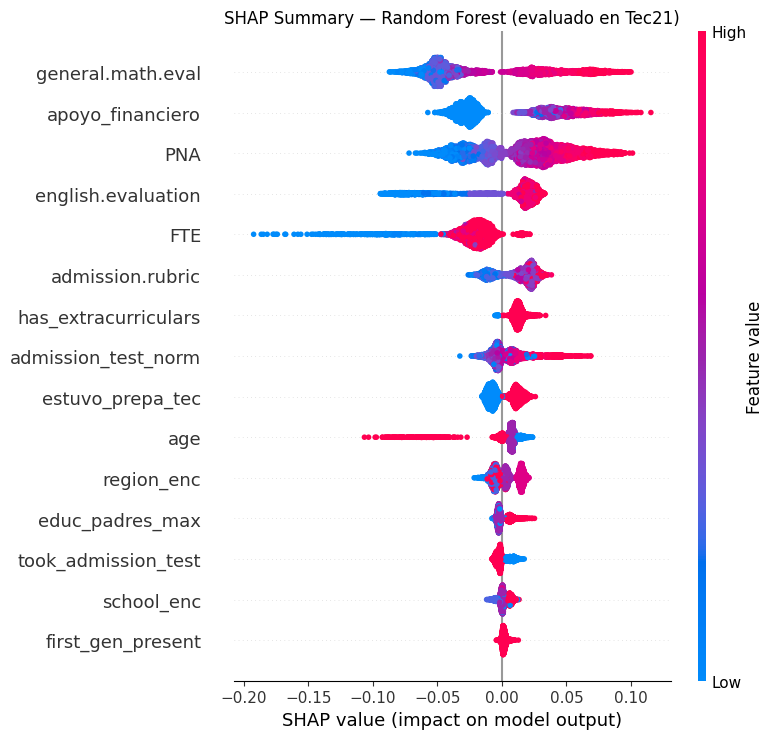

✓ SHAP Random Forest calculado


In [76]:
if SHAP_AVAILABLE:
    shap_results = {}  # {model_name: {feat: mean_abs_shap}}

    # ── Helper: normalizar output de SHAP a matriz 2D (n_samples, n_features) ──
    def get_shap_matrix(shap_vals, class_idx=1):
        """
        Maneja todos los formatos que devuelve shap.TreeExplainer:
          - list [cls0, cls1]:          retorna cls1  (n_samples, n_features)
          - 3D array (n,f,c):           retorna arr[:,:,class_idx]
          - 2D array (n,f):             lo devuelve tal cual
        """
        if isinstance(shap_vals, list):
            arr = np.array(shap_vals[class_idx] if len(shap_vals) > class_idx else shap_vals[0])
        else:
            arr = np.array(shap_vals)
        if arr.ndim == 3:
            arr = arr[:, :, class_idx]   # (n_samples, n_features)
        return arr  # siempre (n_samples, n_features)

    # ── RF SHAP ──────────────────────────────────────────────────────────────
    explainer_rf = shap.TreeExplainer(rf_global)
    raw_rf       = explainer_rf.shap_values(X_te_tec)
    shap_rf      = get_shap_matrix(raw_rf)            # (n_samples, n_features) 2D
    mean_shap_rf = np.abs(shap_rf).mean(axis=0)       # (n_features,) 1D
    shap_results['RandomForest'] = dict(zip(feat_pre, mean_shap_rf.tolist()))

    print(f"shap_rf shape (después de normalizar): {shap_rf.shape}")
    print(f"mean_shap_rf shape: {mean_shap_rf.shape}  — ✓ debe ser 1D ({len(feat_pre)},)")

    # SHAP summary plot RF (recibe 2D matrix)
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_rf, X_te_tec, feature_names=feat_pre,
                      max_display=15, show=False)
    plt.title('SHAP Summary — Random Forest (evaluado en Tec21)')
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'shap_rf_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ SHAP Random Forest calculado")
else:
    print("⚠ SHAP no disponible — instalar con: pip install shap --break-system-packages")
    shap_results = {}

shap_xgb shape (después de normalizar): (4902, 26)
mean_shap_xgb shape: (26,)  — ✓ debe ser 1D (26,)


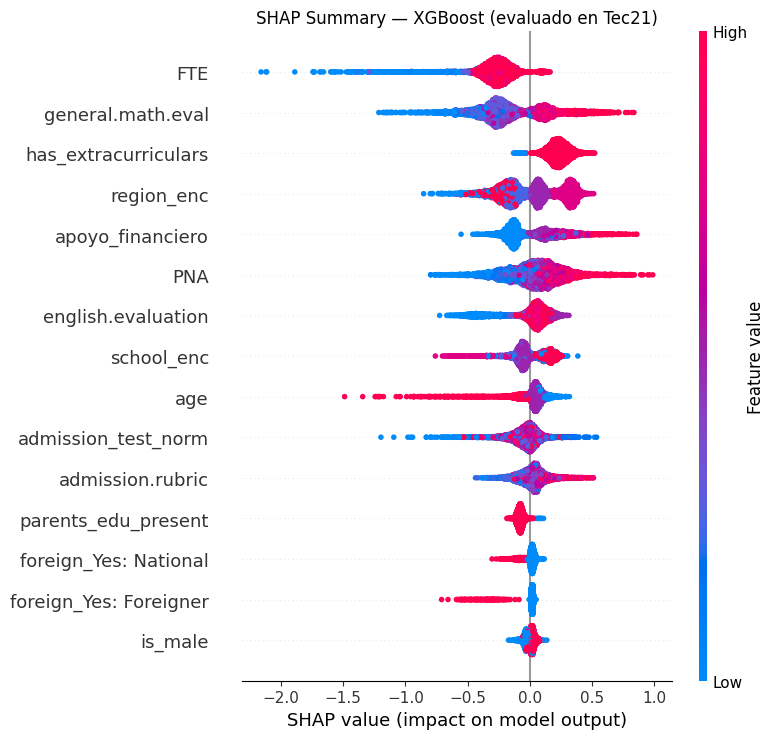

✓ SHAP XGBoost calculado


In [77]:
if SHAP_AVAILABLE and XGB_AVAILABLE and xgb_global is not None:
    explainer_xgb = shap.TreeExplainer(xgb_global)
    raw_xgb       = explainer_xgb.shap_values(X_te_tec)
    shap_xgb      = get_shap_matrix(raw_xgb)             # (n_samples, n_features) 2D
    mean_shap_xgb = np.abs(shap_xgb).mean(axis=0)        # (n_features,) 1D
    shap_results['XGBoost'] = dict(zip(feat_pre, mean_shap_xgb.tolist()))

    print(f"shap_xgb shape (después de normalizar): {shap_xgb.shape}")
    print(f"mean_shap_xgb shape: {mean_shap_xgb.shape}  — ✓ debe ser 1D ({len(feat_pre)},)")

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_xgb, X_te_tec, feature_names=feat_pre,
                      max_display=15, show=False)
    plt.title('SHAP Summary — XGBoost (evaluado en Tec21)')
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'shap_xgb_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ SHAP XGBoost calculado")

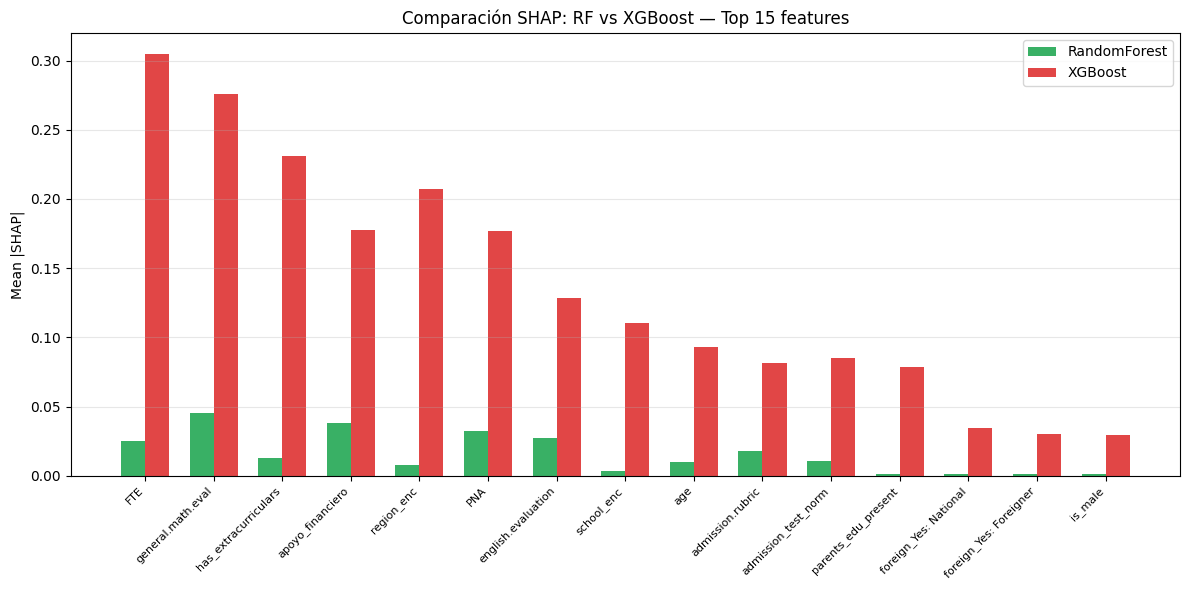


Correlación Spearman entre rankings SHAP (RandomForest vs XGBoost):
  ρ = 0.848  (p = 0.0000)
  ✓ Rankings consistentes entre modelos


In [78]:
if SHAP_AVAILABLE and len(shap_results) >= 2:
    models_shap = list(shap_results.keys())
    all_feats   = list(feat_pre)

    # shap_results guarda {feat: float} — los vals ya son escalares
    rank_dfs = {}
    for mname, shap_dict in shap_results.items():
        vals = np.array([float(shap_dict.get(f, 0)) for f in all_feats])  # forzar 1D
        rank_dfs[mname] = pd.Series(vals, index=all_feats).sort_values(ascending=False)

    # Top 15 por importancia media entre modelos
    mean_imp = pd.concat([s for s in rank_dfs.values()], axis=1).mean(axis=1).sort_values(ascending=False)
    top15 = mean_imp.head(15).index.tolist()

    # Barra comparativa
    n_models = len(models_shap)
    bar_w    = 0.7 / n_models
    fig, ax  = plt.subplots(figsize=(12, 6))
    x = np.arange(len(top15))
    for i, mname in enumerate(models_shap):
        vals = [float(rank_dfs[mname].get(f, 0)) for f in top15]
        offset = (i - (n_models - 1) / 2) * bar_w
        ax.bar(x + offset, vals, bar_w,
               label=mname, color=palette.get(mname, f'C{i}'), alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(top15, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Mean |SHAP|')
    ax.set_title('Comparación SHAP: RF vs XGBoost — Top 15 features')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'shap_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Correlación de Spearman entre rankings
    r1 = [float(rank_dfs[models_shap[0]].get(f, 0)) for f in all_feats]
    r2 = [float(rank_dfs[models_shap[1]].get(f, 0)) for f in all_feats]
    rho, pval = spearmanr(r1, r2)
    print(f"\nCorrelación Spearman entre rankings SHAP ({models_shap[0]} vs {models_shap[1]}):")
    print(f"  ρ = {rho:.3f}  (p = {pval:.4f})")
    print(f"  {'✓ Rankings consistentes entre modelos' if rho >= 0.7 else '⚠ Rankings divergentes — revisar'}")

elif SHAP_AVAILABLE and len(shap_results) == 1:
    mname = list(shap_results.keys())[0]
    print(f"Solo un modelo SHAP disponible ({mname}) — se omite la comparación entre modelos.")
    print("Instala XGBoost para habilitar la comparación.")

## 12. Comparación de Coeficientes Logísticos entre Regímenes

Regresión Logística por régimen:
  PreTec21: AUC=0.669
  Tec21 (self): AUC=0.677


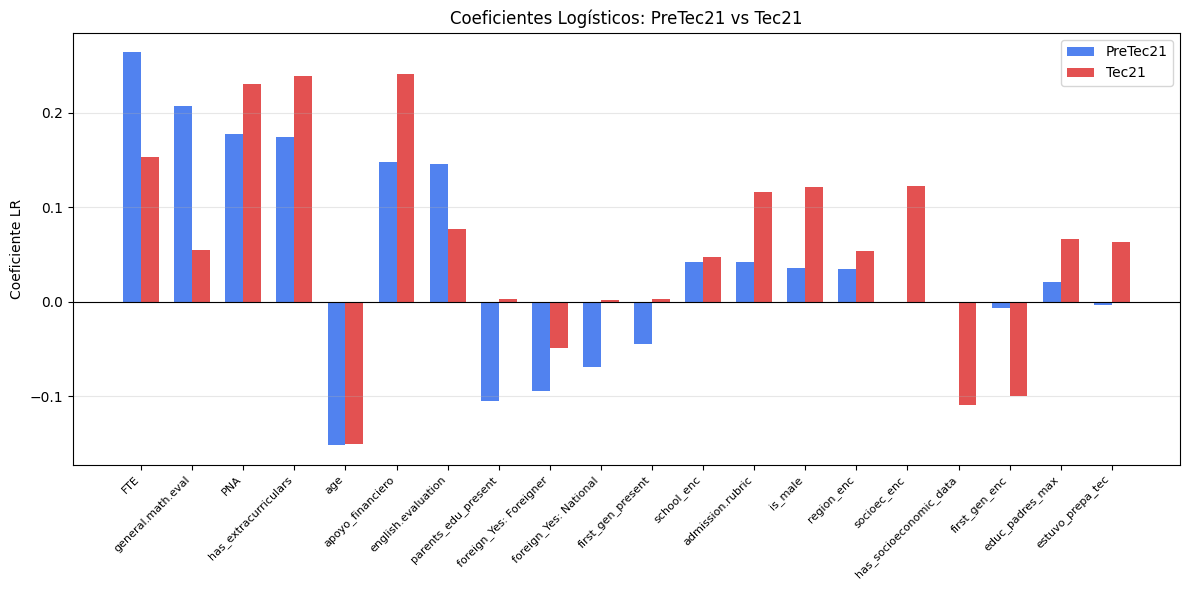

In [79]:
# Entrenar RL independiente en cada régimen (5-fold CV interno)
def train_lr_regime(X_tr, X_te, y_tr, y_te, feat_cols, regime_name):
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)
    lr_reg  = LogisticRegression(class_weight='balanced', max_iter=2000,
                                   random_state=SEED, solver='lbfgs')
    lr_reg.fit(X_tr_sc, y_tr)
    y_proba = lr_reg.predict_proba(X_te_sc)[:, 1]
    auc     = roc_auc_score(y_te, y_proba)
    coefs   = pd.Series(lr_reg.coef_[0], index=feat_cols).sort_values(key=abs, ascending=False)
    print(f"  {regime_name}: AUC={auc:.3f}")
    return lr_reg, coefs, scaler, auc

print("Regresión Logística por régimen:")
lr_reg_pre, coef_pre, sc_pre, auc_lr_pre = train_lr_regime(
    X_tr_pre, X_te_pre, y_tr_pre, y_te_pre, feat_pre, 'PreTec21')
lr_reg_tec, coef_tec, sc_tec, auc_lr_tec = train_lr_regime(
    X_tr_tec, X_te_tec, y_tr_tec, y_te_tec, feat_tec, 'Tec21 (self)')

# Comparar rankings de coeficientes
top_n = 15
feat_union = list(dict.fromkeys(
    list(coef_pre.head(top_n).index) + list(coef_tec.head(top_n).index)))

fig, ax = plt.subplots(figsize=(12, 6))
x       = np.arange(len(feat_union))
w       = 0.35
vals_pre = [coef_pre.get(f, 0) for f in feat_union]
vals_tec = [coef_tec.get(f, 0) for f in feat_union]
ax.bar(x - w/2, vals_pre, w, label='PreTec21', color='#2563eb', alpha=0.8)
ax.bar(x + w/2, vals_tec, w, label='Tec21',    color='#dc2626', alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(feat_union, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Coeficiente LR'); ax.set_title('Coeficientes Logísticos: PreTec21 vs Tec21')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / 'lr_coefs_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Modelos Específicos por Subgrupo/Cluster

Entrenamos un Random Forest **independiente** para cada cluster en PreTec21,
y evaluamos sobre los mismos clusters en Tec21.

In [80]:
def train_rf_cluster(sub_df, feat_cols, cluster_id, regime_name, seed=SEED):
    """Entrena RF en un subgrupo; retorna métricas y SHAP si disponible."""
    cols  = [c for c in feat_cols if c in sub_df.columns and sub_df[c].std() > 0]
    if len(cols) < 3:
        print(f"  Cluster {cluster_id} [{regime_name}]: muy pocas features variantes — omitido")
        return None
    X  = SimpleImputer(strategy='median').fit_transform(sub_df[cols].values.astype(float))
    y  = sub_df[TARGET].values.astype(int)
    if len(np.unique(y)) < 2 or (y==0).sum() < 5:
        print(f"  Cluster {cluster_id} [{regime_name}]: clases insuficientes — omitido")
        return None
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y)
    rf_c = RandomForestClassifier(
        n_estimators=200, max_depth=6, min_samples_leaf=5,
        class_weight='balanced', random_state=seed, n_jobs=-1)
    rf_c.fit(X_tr, y_tr)
    y_proba = rf_c.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_proba) if len(np.unique(y_te)) > 1 else 0.5
    rec = recall_score(y_te, (y_proba >= 0.5).astype(int), zero_division=0)
    f1  = f1_score(y_te, (y_proba >= 0.5).astype(int), zero_division=0)
    # Feature importance
    fi  = pd.Series(rf_c.feature_importances_, index=cols).sort_values(ascending=False)
    print(f"  Cluster {cluster_id} [{regime_name:>8}] n={len(sub_df):>5}  "
          f"AUC={auc:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
    return dict(cluster=cluster_id, regime=regime_name, n=len(sub_df),
                auc=auc, recall=rec, f1=f1,
                model=rf_c, feat_importance=fi, feat_cols=cols)

print("═══ Random Forest por Cluster ═══\n")
cluster_results = []

for regime_name, df_regime in [('PreTec21', df_pre), ('Tec21', df_tec)]:
    print(f"--- {regime_name} ---")
    for k in sorted(df_regime['cluster'].unique()):
        sub = df_regime[df_regime['cluster'] == k].copy()
        res = train_rf_cluster(sub, FEATURE_COLS, k, regime_name)
        if res: cluster_results.append(res)
    print()

print(f"\n✓ Modelos por cluster entrenados: {len(cluster_results)}")

═══ Random Forest por Cluster ═══

--- PreTec21 ---
  Cluster 0 [PreTec21] n= 9498  AUC=0.648  Recall=0.701  F1=0.806
  Cluster 1 [PreTec21] n=21311  AUC=0.627  Recall=0.720  F1=0.802
  Cluster 2 [PreTec21] n=19557  AUC=0.631  Recall=0.766  F1=0.850
  Cluster 3 [PreTec21] n= 2644  AUC=0.623  Recall=0.813  F1=0.853

--- Tec21 ---
  Cluster 0 [   Tec21] n=20141  AUC=0.619  Recall=0.650  F1=0.770
  Cluster 1 [   Tec21] n= 1199  AUC=0.645  Recall=0.889  F1=0.871
  Cluster 2 [   Tec21] n=   38  AUC=0.667  Recall=0.000  F1=0.000
  Cluster 3 [   Tec21] n= 3129  AUC=0.688  Recall=0.743  F1=0.821


✓ Modelos por cluster entrenados: 8



═══ Métricas por Cluster ═══
 cluster   regime     n   auc  recall    f1
       0 PreTec21  9498 0.648   0.701 0.806
       1 PreTec21 21311 0.627   0.720 0.802
       2 PreTec21 19557 0.631   0.766 0.850
       3 PreTec21  2644 0.623   0.813 0.853
       0    Tec21 20141 0.619   0.650 0.770
       1    Tec21  1199 0.645   0.889 0.871
       2    Tec21    38 0.667   0.000 0.000
       3    Tec21  3129 0.688   0.743 0.821


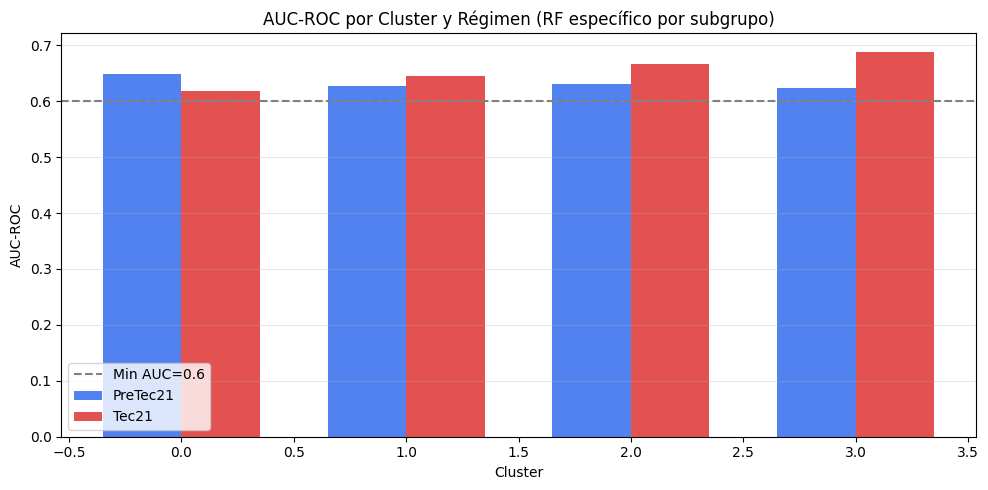

In [81]:
# ── Tabla de métricas por cluster ─────────────────────────────────────────────
if cluster_results:
    df_clust_metrics = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ('model','feat_importance','feat_cols')}
        for r in cluster_results
    ]).round(3)
    print("\n═══ Métricas por Cluster ═══")
    print(df_clust_metrics.to_string(index=False))

    # Visualización: AUC por cluster y régimen
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (regime_name, color) in enumerate([('PreTec21','#2563eb'),('Tec21','#dc2626')]):
        sub = df_clust_metrics[df_clust_metrics['regime']==regime_name]
        ax.bar(sub['cluster'] + i*0.35 - 0.175, sub['auc'],
               0.35, label=regime_name, color=color, alpha=0.8)
    ax.axhline(MIN_AUC, ls='--', color='gray', label=f'Min AUC={MIN_AUC}')
    ax.set_xlabel('Cluster'); ax.set_ylabel('AUC-ROC')
    ax.set_title('AUC-ROC por Cluster y Régimen (RF específico por subgrupo)')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'auc_by_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()

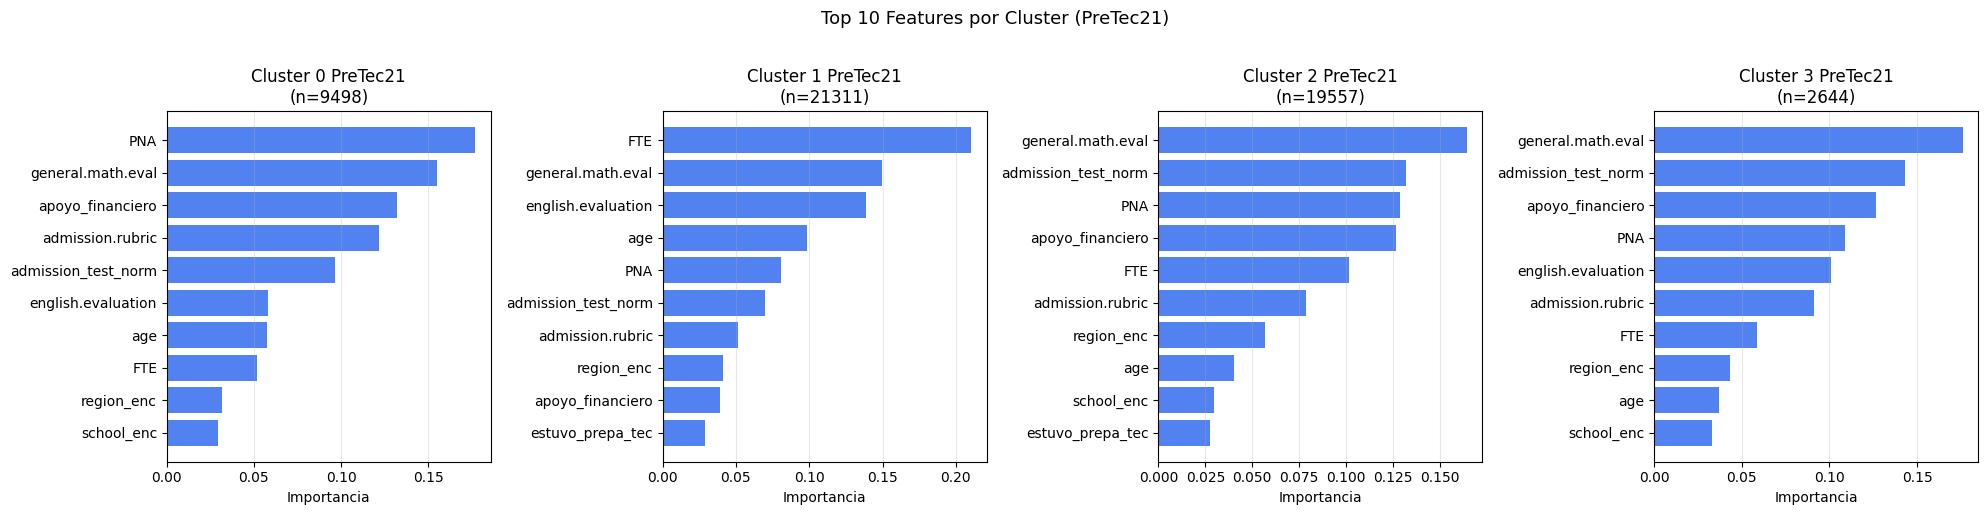

In [82]:
# ── Feature importance por cluster ────────────────────────────────────────────
if cluster_results:
    n_clusters_found = len(set(r['cluster'] for r in cluster_results if r['regime']=='PreTec21'))
    fig, axes = plt.subplots(1, n_clusters_found, figsize=(5*n_clusters_found, 5))
    if n_clusters_found == 1: axes = [axes]
    pre_results = [r for r in cluster_results if r['regime']=='PreTec21']
    for ax, res in zip(axes, pre_results):
        fi = res['feat_importance'].head(10)
        ax.barh(fi.index, fi.values, color='#2563eb', alpha=0.8)
        ax.set_title(f"Cluster {res['cluster']} PreTec21\n(n={res['n']})")
        ax.invert_yaxis(); ax.set_xlabel('Importancia'); ax.grid(axis='x', alpha=0.3)
    plt.suptitle('Top 10 Features por Cluster (PreTec21)', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'feature_importance_by_cluster.png', dpi=150, bbox_inches='tight')
    plt.show()

## 14. Análisis de Invarianza entre Regímenes

Comparamos si los rankings de importancia de variables se mantienen entre PreTec21 y Tec21.  
Una variable es **estable** si su posición relativa varía < 20% en el ranking.

═══ Análisis de Invarianza de Rankings SHAP ═══
Variables estables (Δ < 20%): 25 / 26

                        SHAP_PreTec21  SHAP_Tec21  Rank_PreTec21  Rank_Tec21  Delta_Rank  Delta_Pct  Estable
general.math.eval             0.04090     0.04561            1.0         1.0         0.0        0.0     True
apoyo_financiero              0.03459     0.03786            2.0         2.0         0.0        0.0     True
PNA                           0.03088     0.03253            3.0         3.0         0.0        0.0     True
FTE                           0.02328     0.02503            4.0         5.0         1.0        3.8     True
english.evaluation            0.02140     0.02731            5.0         4.0         1.0        3.8     True
admission.rubric              0.01474     0.01760            6.0         6.0         0.0        0.0     True
admission_test_norm           0.01109     0.01069            7.0         8.0         1.0        3.8     True
estuvo_prepa_tec              0.01025    

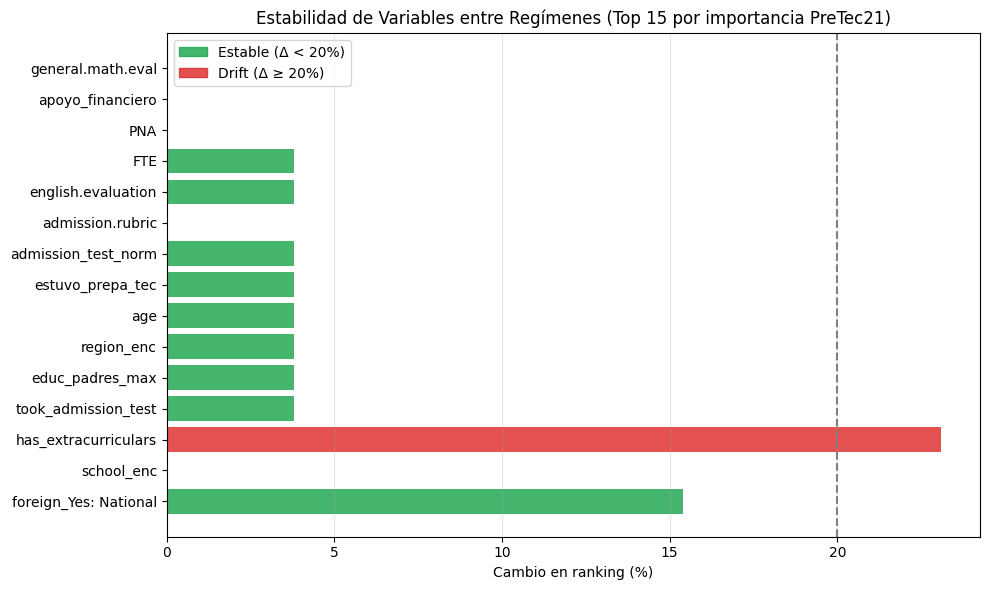


Correlación Spearman PreTec21 vs Tec21: ρ = 0.974  (p = 0.0000)
  ✓ Alta correlación — ranking consistente entre regímenes


In [83]:
if SHAP_AVAILABLE and 'RandomForest' in shap_results:
    # SHAP del mismo RF evaluado en PreTec21 (test interno del régimen)
    explainer_pre  = shap.TreeExplainer(rf_global)
    raw_pre        = explainer_pre.shap_values(X_te_pre)
    shap_pre_mat   = get_shap_matrix(raw_pre)          # (n_samples_pre, n_features) 2D
    mean_shap_pre  = np.abs(shap_pre_mat).mean(axis=0) # (n_features,) 1D

    # SHAP del mismo RF evaluado en Tec21 (ya en shap_rf desde celda 32)
    mean_shap_tec  = np.abs(shap_rf).mean(axis=0)      # (n_features,) 1D

    # Verificar que ambos son 1D antes de crear Series
    assert mean_shap_pre.ndim == 1, f"mean_shap_pre no es 1D: {mean_shap_pre.shape}"
    assert mean_shap_tec.ndim == 1, f"mean_shap_tec no es 1D: {mean_shap_tec.shape}"

    rank_pre_global = pd.Series(mean_shap_pre, index=feat_pre).rank(ascending=False)
    rank_tec_global = pd.Series(mean_shap_tec, index=feat_pre).rank(ascending=False)

    inv_df = pd.DataFrame({
        'SHAP_PreTec21' : pd.Series(mean_shap_pre, index=feat_pre).round(5),
        'SHAP_Tec21'    : pd.Series(mean_shap_tec, index=feat_pre).round(5),
        'Rank_PreTec21' : rank_pre_global,
        'Rank_Tec21'    : rank_tec_global,
    })
    inv_df['Delta_Rank'] = (inv_df['Rank_Tec21'] - inv_df['Rank_PreTec21']).abs()
    inv_df['Delta_Pct']  = (inv_df['Delta_Rank'] / len(inv_df) * 100).round(1)
    inv_df['Estable']    = inv_df['Delta_Pct'] < 20
    inv_df = inv_df.sort_values('Rank_PreTec21')

    n_stable = inv_df['Estable'].sum()
    print("═══ Análisis de Invarianza de Rankings SHAP ═══")
    print(f"Variables estables (Δ < 20%): {n_stable} / {len(inv_df)}")
    print()
    print(inv_df.to_string())

    # Visualización — drift en rankings Top 15
    top15_inv  = inv_df.head(15)
    colors_inv = ['#16a34a' if e else '#dc2626' for e in top15_inv['Estable']]
    fig, ax    = plt.subplots(figsize=(10, 6))
    ax.barh(top15_inv.index, top15_inv['Delta_Pct'], color=colors_inv, alpha=0.8)
    ax.axvline(20, ls='--', color='gray')
    ax.set_xlabel('Cambio en ranking (%)')
    ax.set_title('Estabilidad de Variables entre Regímenes (Top 15 por importancia PreTec21)')
    ax.invert_yaxis(); ax.grid(axis='x', alpha=0.3)
    stable_patch = mpatches.Patch(color='#16a34a', alpha=0.8, label='Estable (Δ < 20%)')
    drift_patch  = mpatches.Patch(color='#dc2626', alpha=0.8, label='Drift (Δ ≥ 20%)')
    ax.legend(handles=[stable_patch, drift_patch])
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'invariance_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    rho_inv, p_inv = spearmanr(rank_pre_global.values, rank_tec_global.values)
    print(f"\nCorrelación Spearman PreTec21 vs Tec21: ρ = {rho_inv:.3f}  (p = {p_inv:.4f})")
    verdict = '✓ Alta correlación — ranking consistente entre regímenes' \
              if rho_inv >= 0.7 else '⚠ Baja correlación — el perfil de importancia cambia entre regímenes'
    print(f"  {verdict}")
else:
    print("SHAP no disponible o RF no entrenado — omitiendo análisis de invarianza.")
    print("Instala SHAP con: pip install shap --break-system-packages")

## 15. Resumen y Respuesta a la Pregunta de Investigación

In [84]:
print("=" * 65)
print("RESUMEN DE RESULTADOS — Entrega 2")
print("=" * 65)

print("\n📊 CLUSTERING (K-Means por Régimen)")
print(f"  K = {K_CLUSTERS} clusters")
print(f"  Silhouette  PreTec21: {sil_pre:.3f}  {'✓' if sil_pre >= MIN_SILHOUETTE else '✗'}")
print(f"  Silhouette  Tec21   : {sil_tec:.3f}  {'✓' if sil_tec >= MIN_SILHOUETTE else '✗'}")
print(f"  Davies-Bouldin PreTec21: {db_pre:.3f}  {'✓' if db_pre <= MAX_DB else '✗'}")
print(f"  Davies-Bouldin Tec21   : {db_tec:.3f}  {'✓' if db_tec <= MAX_DB else '✗'}")

print("\n🤖 MODELOS SUPERVISADOS (Entrenado PreTec21 → Evaluado Tec21)")
for r in results_global:
    ok = '✓' if r['auc'] >= MIN_AUC else '✗'
    print(f"  {ok} {r['model']:<28} AUC={r['auc']:.3f}  Recall={r['recall']:.3f}  F1={r['f1']:.3f}")

if cluster_results:
    print("\n🔍 MODELOS POR SUBGRUPO/CLUSTER")
    df_clust_tmp = pd.DataFrame([
        {k: v for k, v in r.items() if k not in ('model','feat_importance','feat_cols')}
        for r in cluster_results
    ])
    for _, row in df_clust_tmp.iterrows():
        ok = '✓' if row['auc'] >= MIN_AUC else '✗'
        print(f"  {ok} Cluster {int(row['cluster'])} [{row['regime']:<8}]  "
              f"n={int(row['n']):>5}  AUC={row['auc']:.3f}  Recall={row['recall']:.3f}")

print("\n🎯 PREGUNTA DE INVESTIGACIÓN:")
print("  ¿Existe un perfil de deserción invariante entre PreTec21 y Tec21?")

if SHAP_AVAILABLE and 'RandomForest' in shap_results:
    pct_stable = inv_df['Estable'].mean() * 100
    print(f"\n  El {pct_stable:.0f}% de las variables principales mantienen")
    print(f"  posición relativa < 20% de cambio entre regímenes.")
    print(f"  Correlación de Spearman de rankings: ρ = {rho_inv:.3f}")
    if rho_inv >= 0.7 and pct_stable >= 60:
        print("\n  → EVIDENCIA de perfil INVARIANTE: los predictores")
        print("    clave se mantienen consistentes entre modelos educativos.")
    else:
        print("\n  → El perfil MUTA entre regímenes: los predictores")
        print("    cambian de importancia relativa en Tec21.")
else:
    print("\n  → Instalar SHAP para análisis de invarianza completo.")

print("\n" + "=" * 65)

RESUMEN DE RESULTADOS — Entrega 2

📊 CLUSTERING (K-Means por Régimen)
  K = 4 clusters
  Silhouette  PreTec21: 0.177  ✗
  Silhouette  Tec21   : 0.177  ✗
  Davies-Bouldin PreTec21: 1.683  ✗
  Davies-Bouldin Tec21   : 1.594  ✗

🤖 MODELOS SUPERVISADOS (Entrenado PreTec21 → Evaluado Tec21)
  ✓ LogisticRegression           AUC=0.648  Recall=1.000  F1=0.955
  ✗ DecisionTree                 AUC=0.583  Recall=1.000  F1=0.955
  ✓ RandomForest                 AUC=0.655  Recall=1.000  F1=0.955
  ✓ XGBoost                      AUC=0.647  Recall=1.000  F1=0.955

🔍 MODELOS POR SUBGRUPO/CLUSTER
  ✓ Cluster 0 [PreTec21]  n= 9498  AUC=0.648  Recall=0.701
  ✓ Cluster 1 [PreTec21]  n=21311  AUC=0.627  Recall=0.720
  ✓ Cluster 2 [PreTec21]  n=19557  AUC=0.631  Recall=0.766
  ✓ Cluster 3 [PreTec21]  n= 2644  AUC=0.623  Recall=0.813
  ✓ Cluster 0 [Tec21   ]  n=20141  AUC=0.619  Recall=0.650
  ✓ Cluster 1 [Tec21   ]  n= 1199  AUC=0.645  Recall=0.889
  ✓ Cluster 2 [Tec21   ]  n=   38  AUC=0.667  Recall=0.000
